In [ ]:
import pandas as pd # To manage data and spreadsheet files
import yfinance as yf # The financial database we will leverage

: 

We can now download, e.g., specific stock data. Lets do that for the Apple stock, named 'AAPL'.

In [57]:
# Download apple stock data for the last month
apple_data = yf.download('AAPL', period='12mo')
# Flatten the column MultiIndex to access columns easily
apple_data.columns = apple_data.columns.get_level_values(0)

[*********************100%***********************]  1 of 1 completed


The second line is done because right now, we download data that is stored in a larger dataframe for different companies. So every dataframe is still assigned a company, in this case Apple, so we have a `Multiindex`. To get the raw data, we essentially would need to call `apple_data.['Close']['AAPL']`, otherwise we get a type mismatch. To avoid doing that for this single company data, we can strip away the second level by callling `.get_level_values(0)`.

The data is stored as a `pandas dataframe` (read more on that [here](https://pandas.pydata.org/docs/getting_started/index.html)). This is like a spreadsheet, consisting of colums (called 'series') of a certain datatype. While the whole dataframe will be huge, we can get a glimpse of what it looks like by using `dataframe.head()`. This displays the first 5 rows of the dataframe.

In [58]:
# Display the data
apple_data.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2025-01-10,235.783600,239.078694,231.950928,238.929361,61710900
2025-01-13,233.344635,233.613424,228.685713,232.478557,49630700
2025-01-14,232.229691,235.056900,231.423340,233.693073,39435300
2025-01-15,236.799011,237.884115,233.374497,233.583558,39832000
2025-01-16,227.232285,236.938386,227.003324,236.281370,71759100


As we can see, the data is structured by showing us the price (probably in USD) of different categories, to which we will come later. The ticker ('APPL') shows for which stock, and we have the data indexed by the date.

For a generic dataframe, we can see the shape of the dataframe by using `dataframe.shape`, how the different columns are named by calling `dataframe.columns`  and general information by using `dataframe.info()`.

In [59]:
print("The shape of the dataframe: " ,apple_data.shape)
print("The columns: ", apple_data.columns)
print("Dataframe info:")
apple_data.info()

The shape of the dataframe:  (251, 5)
The columns:  Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
Dataframe info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2025-01-10 to 2026-01-09
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   251 non-null    float64
 1   High    251 non-null    float64
 2   Low     251 non-null    float64
 3   Open    251 non-null    float64
 4   Volume  251 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.8 KB


We can select a specific column by using `column_data = dataframe['colum_name']`. Let us extract the closing prices of the Apple stock

In [60]:
close_prices = apple_data['Close']
print("Close Prices:")
print(close_prices)

Close Prices:
Date
2025-01-10    235.783600
2025-01-13    233.344635
2025-01-14    232.229691
2025-01-15    236.799011
2025-01-16    227.232285
                 ...    
2026-01-05    267.260010
2026-01-06    262.359985
2026-01-07    260.329987
2026-01-08    259.040009
2026-01-09    259.369995
Name: Close, Length: 251, dtype: float64


If we want to select a specific row, we can use `row_data = dataframe.loc['row_label']` (the alternative for searching for the row index is `.iloc[index]`). In our case, the row index is the leftmost entry. Let us look up the data for the '2025-12-15':

In [61]:
spec_day_data = apple_data.loc['2025-12-15']
print("Data for 15th Dec 2025:")
print(spec_day_data)

Data for 15th Dec 2025:
Price
Close     2.741100e+02
High      2.801500e+02
Low       2.728400e+02
Open      2.801500e+02
Volume    5.040910e+07
Name: 2025-12-15 00:00:00, dtype: float64


For a specific series, we can get a glimpse at easy to calculate statistics using the `dataframe.describe()` method. This calculates a count (how many entries), the mean, standard deviation, min and max as well as the percentiles.

In [62]:
close_prices.describe()

count    251.000000
mean     232.321350
std       26.975784
min      171.832428
25%      209.573761
50%      229.807220
75%      256.031807
max      286.190002
Name: Close, dtype: float64

We can also plot the data in the dataframes easily using `matplotlib` in a very intuitive manner:

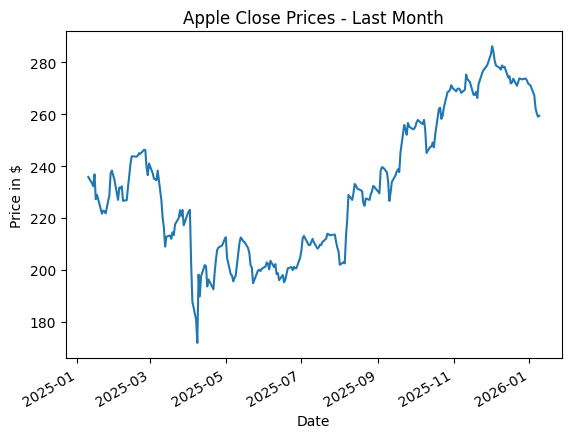

In [63]:
import matplotlib.pyplot as plt

close_prices.plot(title='Apple Close Prices - Last Month', ylabel='Price in $', xlabel='Date')
plt.show()

We can easily filter for conditions in the usual manner. E.g., if we want to find only the days where the closing price is higher than the opening price (i.e., the stock gained value over the day), we can create this filtered dataset like this:

In [64]:
green_days = apple_data[apple_data['Close'] > apple_data['Open']]
# This is called green days since the stock is usually displayed in green on stock charts

By the same method, we can generate new data. A common measure of 'volatility' is the differene between the maximum and minimum stock price (the 'HIGH' and 'LOW') of the day. We can create a new entry into our dataframe called 'Daily_Range' and assign it the difference between the high and low:

In [65]:
apple_data['Daily_Range'] = apple_data['High'] - apple_data['Low']
print("Apple Data with Daily Range:")
print(apple_data.head())

Apple Data with Daily Range:
Price            Close        High         Low        Open    Volume  \
Date                                                                   
2025-01-10  235.783600  239.078694  231.950928  238.929361  61710900   
2025-01-13  233.344635  233.613424  228.685713  232.478557  49630700   
2025-01-14  232.229691  235.056900  231.423340  233.693073  39435300   
2025-01-15  236.799011  237.884115  233.374497  233.583558  39832000   
2025-01-16  227.232285  236.938386  227.003324  236.281370  71759100   

Price       Daily_Range  
Date                     
2025-01-10     7.127766  
2025-01-13     4.927710  
2025-01-14     3.633560  
2025-01-15     4.509618  
2025-01-16     9.935062  


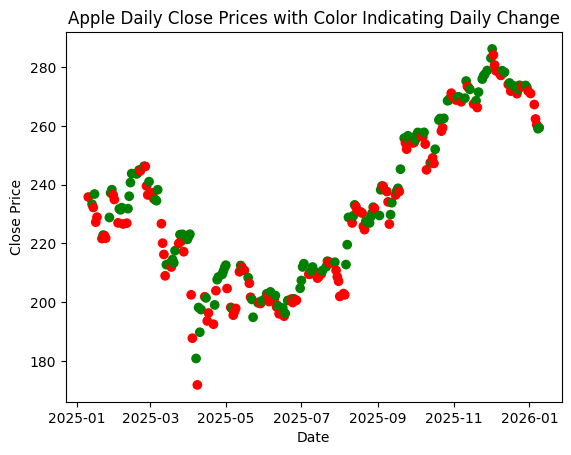

In [66]:
# Create a data entry for the daily change in the prices
apple_data['Daily_Change'] = apple_data['Close'] - apple_data['Open']

# Plot the stock price and color it green if it went up that day and red if it went down
colors = ['green' if change > 0 else 'red' for change in apple_data['Daily_Change']]
plt.scatter(apple_data.index, apple_data['Close'], c=colors)
plt.title('Apple Daily Close Prices with Color Indicating Daily Change')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.show()

Lets get more into detail. We can look at the days where the Stock had the largest price increase over the day. For this, we look at the daily change and sort the data in descending fashion:

In [67]:
top_gainers = apple_data.sort_values(by='Daily_Change', ascending=False)
top_gainers.head()

Price,Close,High,Low,Open,Volume,Daily_Range,Daily_Change
Date,,,,,,,
2025-04-09,198.172348,199.926345,171.304218,171.364011,184395900,28.622127,26.808337
2025-04-11,197.474731,198.859994,185.425936,185.465808,87435900,13.434058,12.008923
2025-08-08,228.868134,230.514661,218.789348,220.366030,113854000,11.725313,8.502103
2025-09-22,255.831985,256.391471,247.879703,248.059536,105517400,8.511768,7.772449
2025-08-06,212.801956,214.927486,205.158046,205.197971,108483100,9.769439,7.603985


Pandas also allows us to easily create a `moving average` by employing the `rolling` method. By calling `dataframe.rolling(window=n)` we create a dataframe that is looking at windows of size `n`. We can calculate the average and standard deviation from that window:

In [68]:
MA5 = apple_data['Close'].rolling(window=5) # create the 5 day moving average
apple_data['MA5'] = MA5.mean() # assign the moving average to a new column
apple_data['MA5_volatility'] = MA5.std() # assign the moving average volatility to a new column

apple_data[['MA5', 'MA5_volatility']].tail() # The first four entries are empty since there is not enough data to calculate the moving average


Price,MA5,MA5_volatility
Date,,
2026-01-05,271.394000,2.544357
2026-01-06,269.113995,4.356556
2026-01-07,266.563995,5.119462
2026-01-08,264.000000,5.013184
2026-01-09,261.671997,3.381079


We can try to visualise this moving average by plotting it

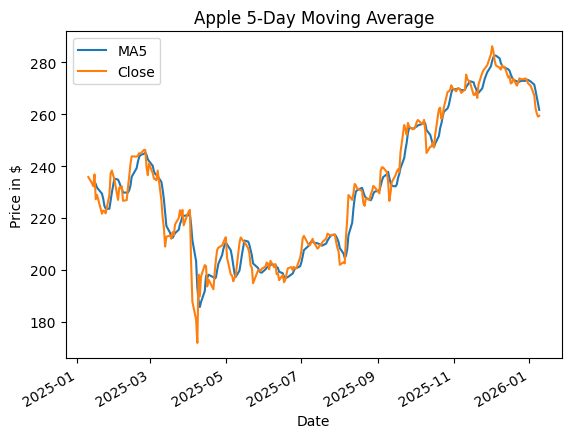

In [69]:
apple_data['MA5'].plot(title='Apple 5-Day Moving Average', ylabel='Price in $', xlabel='Date', label='MA5')
apple_data['Close'].plot(label='Close')
plt.legend()
plt.show()

We see that since the average is calculated using the four days before it, we are a bit "lagging" behind the actual price development. The reason for calculating the rolling average in this lagging fashion is that the market only has information from the past.

However, for data analysis, it might be useful to use a centric rolling average. Lets calculate both and compare them

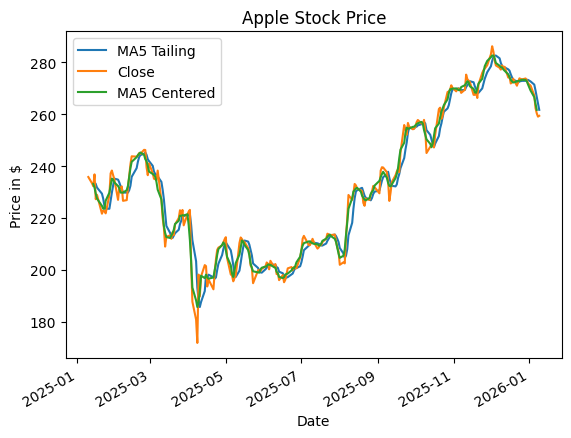

In [70]:
MA5_centered = apple_data['Close'].rolling(window=5, center=True)
apple_data['MA5_centered'] = MA5_centered.mean()
apple_data['MA5_centered_volat'] = MA5_centered.std()

apple_data['MA5'].plot(title='Apple Stock Price', ylabel='Price in $', xlabel='Date', label='MA5 Tailing')
apple_data['Close'].plot(label='Close')
apple_data['MA5_centered'].plot(label='MA5 Centered')

plt.legend()
plt.show()

A common strategy to identify momentum crossovers in stock prices is to compare a short and long average (e.g., a 5 and 20 day rollin average). For this, we need Stockprices for a longer time range. Lets import the apple stock price for the last year

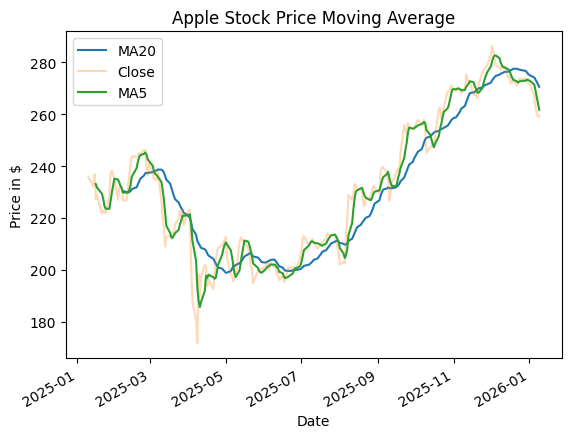

In [74]:
MA20 = apple_data['Close'].rolling(window=20)
apple_data['MA20'] = MA20.mean()
apple_data['MA20_volatility'] = MA20.std()

apple_data['MA20'].plot(title='Apple Stock Price Moving Average', ylabel='Price in $', xlabel='Date', label='MA20')
apple_data['Close'].plot(label='Close', alpha = 0.3)
apple_data['MA5'].plot(label='MA5')
plt.legend()
plt.show()

The idea being that if the short term average (5 days) is below the long term average (20 days), the market in general is declining (one speaks about a 'BEAR MARKET'). This can be seen in the region between March and May of 20205, where the green line is always below the blue line, a bear market. And this is the region where the stock prices on average have gone down.
In May, the green line for the first time crossed for a significant time the blue line, and indeed the prices went up, or at least the downfall was stopped. After July 2025, the green line is almost always above the blue line, indicating a 'BULL MARKET' with increasing stock value.

Let us compute whether the short average is above or below the long average:

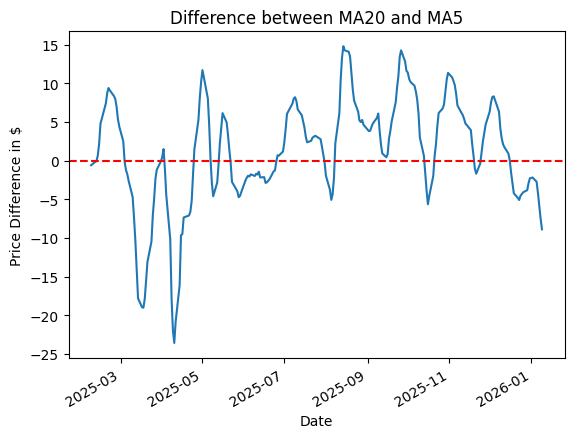

In [76]:
apple_data['MA_Diff'] = apple_data['MA5'] - apple_data['MA20']
apple_data['MA_Diff'].plot(title='Difference between MA20 and MA5', ylabel='Price Difference in $', xlabel='Date')
plt.axhline(0, color='red', linestyle='--')  # Line at y=0 for reference
plt.show()